In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Load the dataset
file_name = "House Price Prediction Dataset.csv"

try:
    df = pd.read_csv(file_name)
    print("Local file loaded successfully!")
    print(f"Dataset Shape: {df.shape}")
    print(df.head())
except FileNotFoundError:
    print("Error: File not found! Check the file name and path.")
    

Local file loaded successfully!
Dataset Shape: (2000, 10)
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [4]:
# Missing values check 
print(df.isnull().sum())

# Categorical columns (like Location) convert into numbers if they exist
df = pd.get_dummies(df, drop_first=True)

# Target variable (Price) and Features (Size, Bedrooms, etc.) separate them
X = df.drop('Price', axis=1) 
y = df['Price']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [5]:
# Gradient Boosting Model
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
predictions = model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

Mean Absolute Error: 243921.84
Root Mean Squared Error: 284314.77


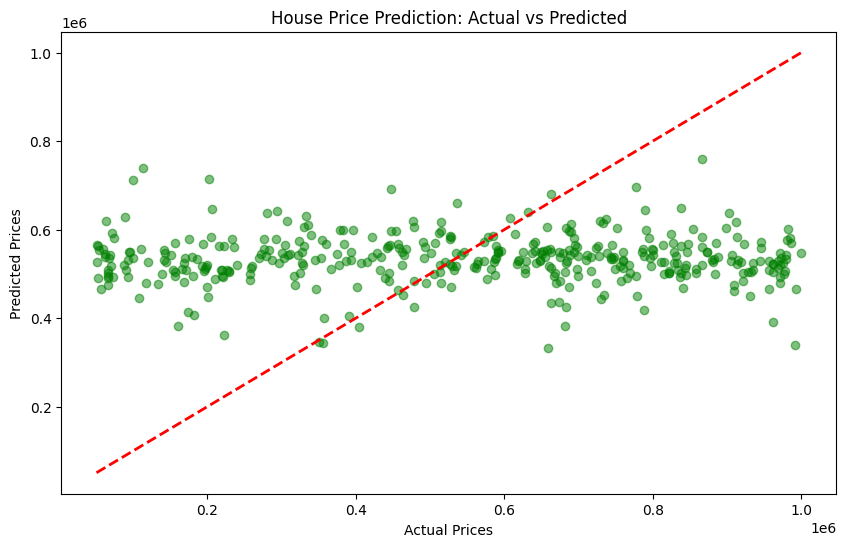

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("House Price Prediction: Actual vs Predicted")
plt.show()